0. Imports y carga del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("talk")

In [2]:
df = pd.read_csv("../data/processed/tweets_features.csv")
df.head()

,id,author,text,created_at,lang,source,clean_text,tokens,n_tokens,n_chars,...,candidate,sentiment_label,sentiment_pos,sentiment_neu,sentiment_neg,emotion_label,emotion_joy,emotion_anger,emotion_sadness,emotion_fear
0,IvanCepeda_0,desconocido,¿Por qué le da tanto susto a #IvánCepeda senta...,2025-11-19 19:10:01,es,#IvanCepeda,por qué le da tanto susto a sentarse frente a ...,"['susto', 'sentarse', 'frente', 'abelardo', 'b...",11,129,...,Ivan Cepeda,NEG,0.008462,0.052220,0.939318,fear,0.009201,0.242934,0.035184,0.306337
1,IvanCepeda_1,desconocido,#IvánCepeda toma la delantera en la carrera pr...,2025-11-19 19:10:01,es,#IvanCepeda,toma la delantera en la carrera presidencial y...,"['toma', 'delantera', 'carrera', 'presidencial...",24,254,...,Ivan Cepeda,NEU,0.427427,0.536161,0.036413,others,0.003403,0.000241,0.000752,0.000703
2,IvanCepeda_2,desconocido,El exgobernador Zuluaga anunció este 19 de nov...,2025-11-19 19:10:01,es,#IvanCepeda,el exgobernador zuluaga anunció este 19 de nov...,"['exgobernador', 'zuluaga', 'anuncio', 'noviem...",21,302,...,Ivan Cepeda,NEG,0.007140,0.181386,0.811474,others,0.000734,0.011062,0.027331,0.003189
3,IvanCepeda_3,desconocido,#IvanCepeda: El senador pudiera ser uno de los...,2025-11-19 19:10:01,es,#IvanCepeda,el senador pudiera ser uno de los candidatos e...,"['senador', 'pudiera', 'candidatos', 'proximas...",14,198,...,Ivan Cepeda,NEG,0.008179,0.162284,0.829537,others,0.000782,0.015373,0.019060,0.031577
4,IvanCepeda_4,desconocido,#IvánCepeda es hoy el candidato presidencial c...,2025-11-19 19:10:01,es,#IvanCepeda,es hoy el candidato presidencial con mayor int...,"['candidato', 'presidencial', 'mayor', 'intenc...",17,222,...,Ivan Cepeda,POS,0.497502,0.467473,0.035025,others,0.001112,0.000265,0.000419,0.000677


1. Distribución del sentimiento global

C:\Users\juanp\AppData\Local\Temp\ipykernel_1816\3387238696.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="sentiment_label", palette="viridis")


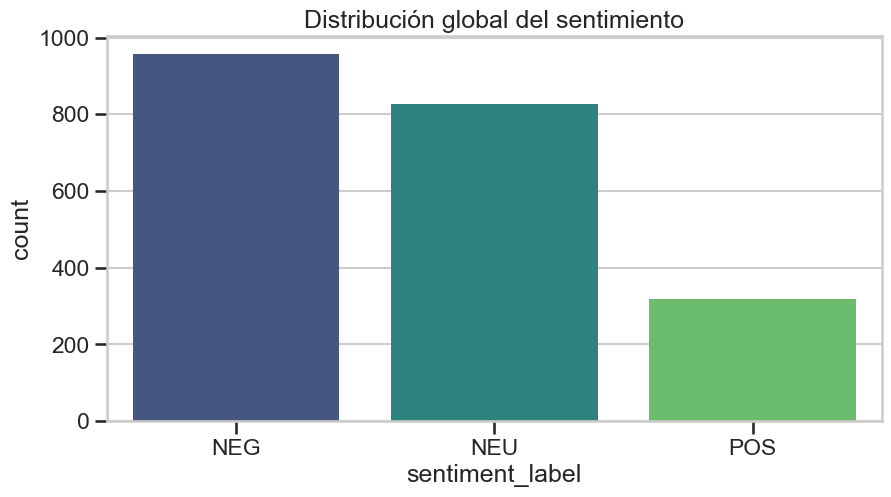

In [3]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x="sentiment_label", palette="viridis")
plt.title("Distribución global del sentimiento")
plt.show()

3. Sentimiento por candidato

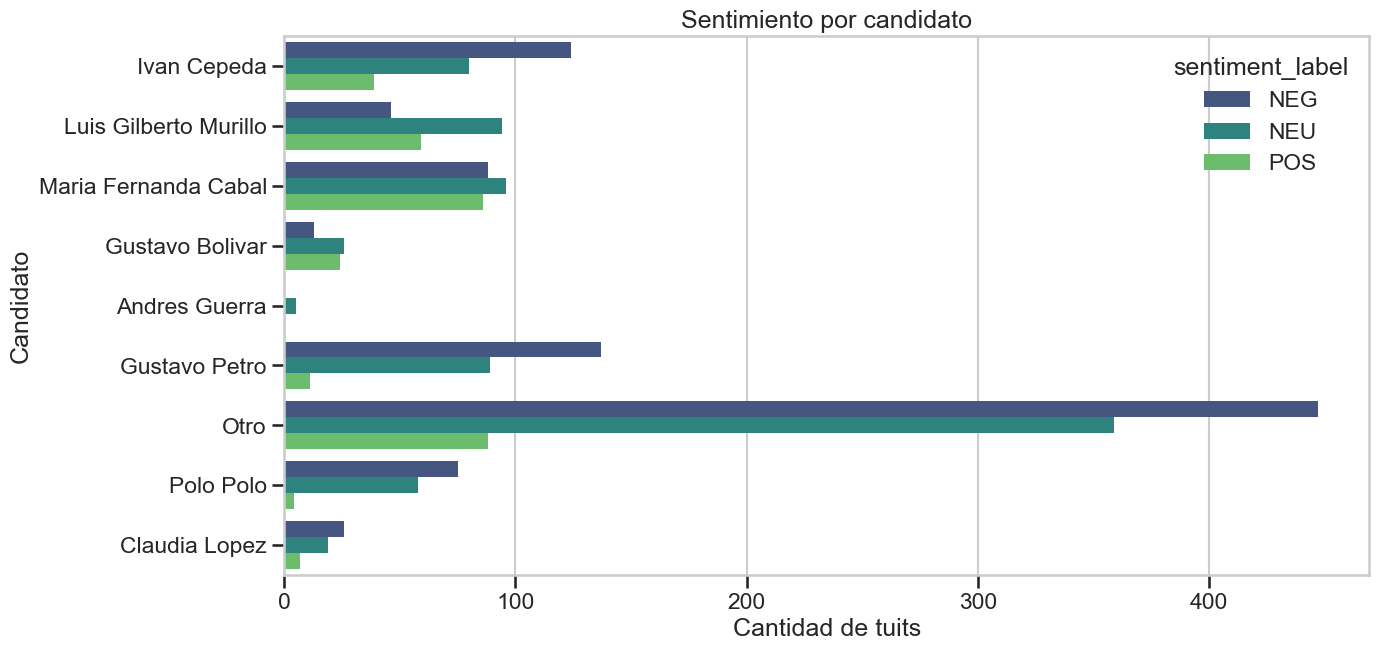

In [4]:
plt.figure(figsize=(14,7))
sns.countplot(
    data=df,
    y="candidate",
    hue="sentiment_label",
    palette="viridis"
)
plt.title("Sentimiento por candidato")
plt.xlabel("Cantidad de tuits")
plt.ylabel("Candidato")
plt.show()


4. Sentimiento promedio (score numérico)

C:\Users\juanp\AppData\Local\Temp\ipykernel_1816\4153903785.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


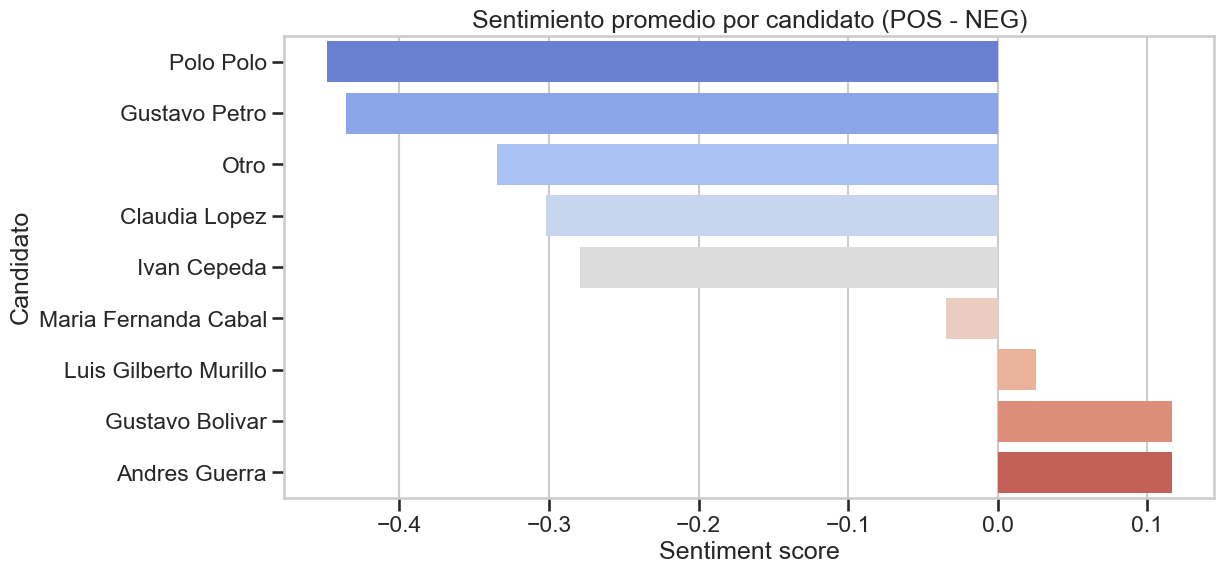

In [5]:
df["sentiment_score"] = df["sentiment_pos"] - df["sentiment_neg"]

sentiment_means = df.groupby("candidate")["sentiment_score"].mean().sort_values()

plt.figure(figsize=(12,6))
sns.barplot(
    x=sentiment_means.values,
    y=sentiment_means.index,
    palette="coolwarm"
)
plt.title("Sentimiento promedio por candidato (POS - NEG)")
plt.xlabel("Sentiment score")
plt.ylabel("Candidato")
plt.show()


5. Sentimiento en el tiempo

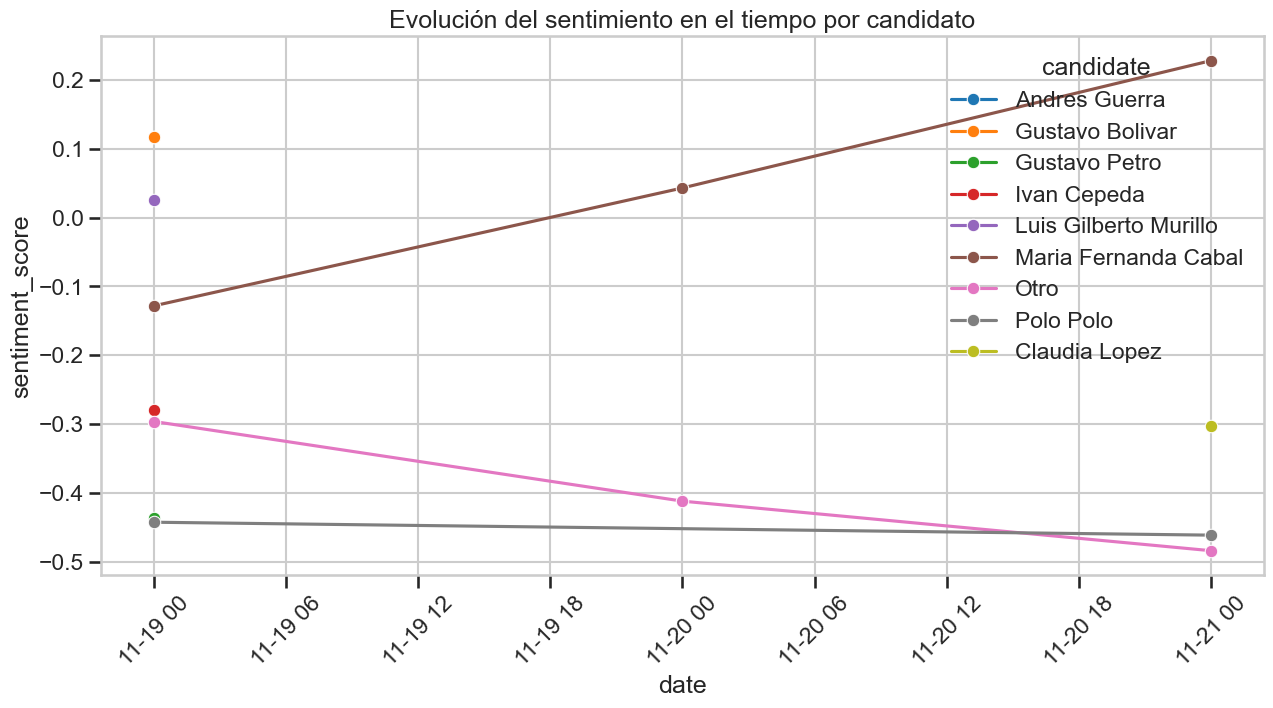

In [6]:
df["created_at"] = pd.to_datetime(df["created_at"])
df["date"] = df["created_at"].dt.date

daily = df.groupby(["date","candidate"])["sentiment_score"].mean().reset_index()

plt.figure(figsize=(15,7))
sns.lineplot(
    data=daily,
    x="date",
    y="sentiment_score",
    hue="candidate",
    marker="o"
)
plt.title("Evolución del sentimiento en el tiempo por candidato")
plt.xticks(rotation=45)
plt.show()


6. Distribución de emociones

C:\Users\juanp\AppData\Local\Temp\ipykernel_1816\3201466863.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="emotion_label", palette="mako")


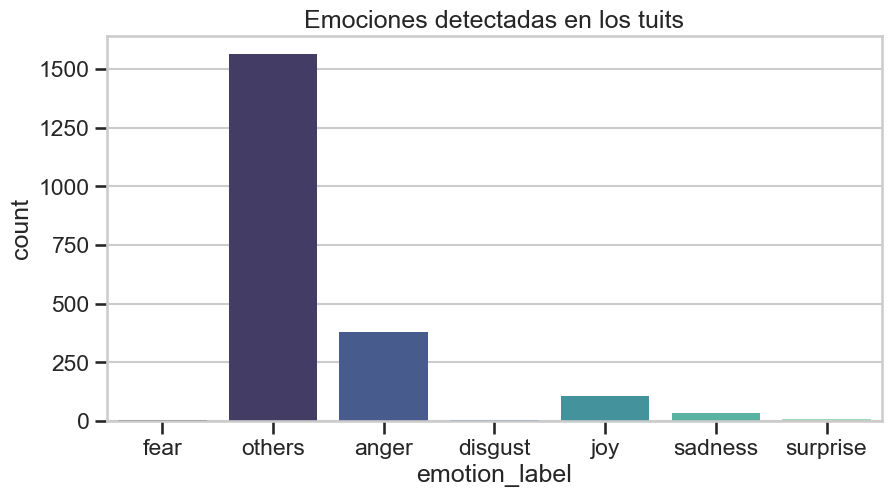

In [7]:
if "emotion_label" in df.columns:
    plt.figure(figsize=(10,5))
    sns.countplot(data=df, x="emotion_label", palette="mako")
    plt.title("Emociones detectadas en los tuits")
    plt.show()


7. Emoción por candidato

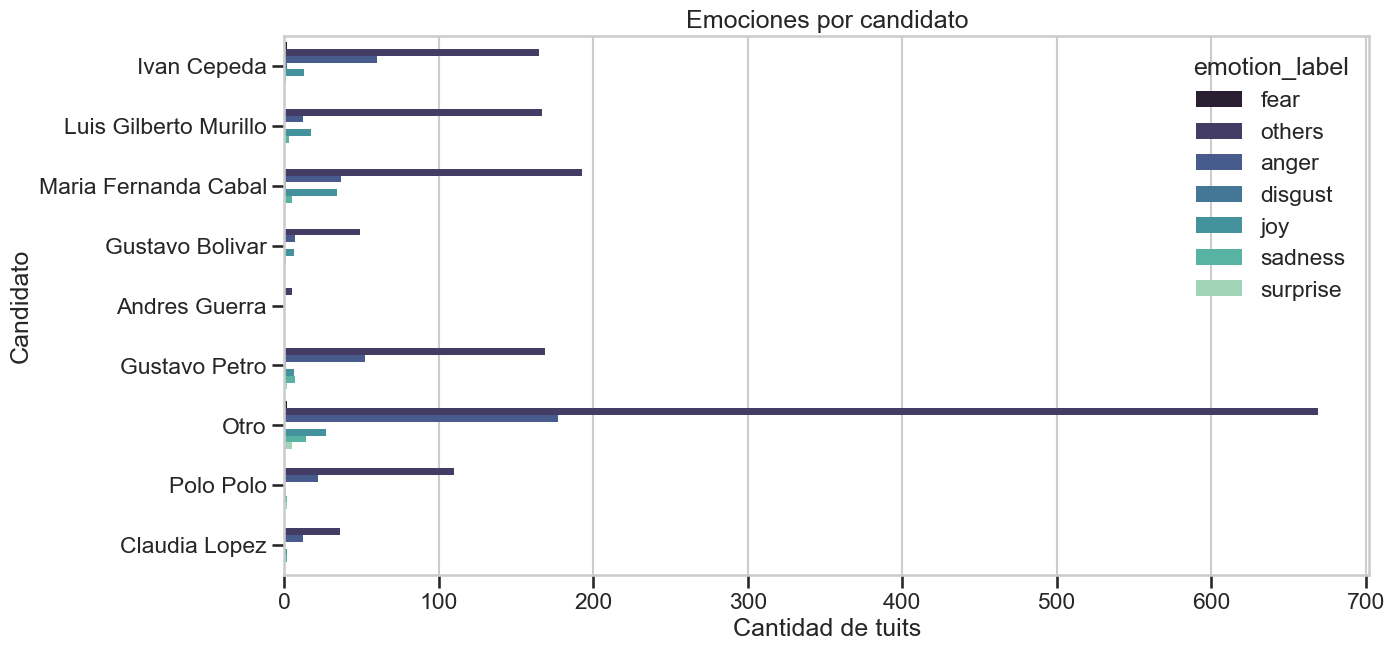

In [8]:
if "emotion_label" in df.columns:
    plt.figure(figsize=(14,7))
    sns.countplot(
        data=df,
        y="candidate",
        hue="emotion_label",
        palette="mako"
    )
    plt.title("Emociones por candidato")
    plt.xlabel("Cantidad de tuits")
    plt.ylabel("Candidato")
    plt.show()
